# Clustering por posición y comparación de nivel entre ligas

Objetivo: agrupar jugadores por **estilo/nivel de rendimiento ofensivo**
dentro de su misma posición (un delantero solo se compara contra otros
delanteros), y luego ver **qué proporción de cada liga cae en cada grupo**
— esa proporción es la métrica de "nivel internacional": si La Liga tiene
más delanteros en el cluster "alto rendimiento" que Liga MX, es una señal
cuantitativa de diferencia de nivel entre ligas.

## Decisiones de diseño
- **Un clustering por posición** (FW, MF, DF por separado) — mezclar
  posiciones distorsionaría todo, un defensa central con 2 goles/90 no
  existe, pero para un delantero es bajo.
- **Porteros (GK) excluidos** — las métricas disponibles (goles, asistencias)
  no dicen nada del rendimiento de un portero; haría falta otra fuente
  (paradas, goles evitados) que no tenemos.
- **Features**: `goals_per90, assists_per90, goals_assists_per90,
  goals_pens_per90, cards_yellow, cards_red` — las mismas 6 del PCA en `09`,
  estandarizadas (z-score). No metemos `age` ni `minutes_90s` porque no son
  "estilo/nivel", son contexto.
- **K-Means**, número de clusters elegido con silhouette score (probado
  2-6 para cada posición). El resultado favoreció k=3 en las tres
  posiciones (o muy cerca del óptimo), así que usamos k=3 para las tres —
  facilita comparar entre posiciones con las mismas etiquetas
  (Bajo/Medio/Alto rendimiento ofensivo).
- Los clusters se agrupan **sin distinguir liga ni temporada** — el pool es
  todo el panel junto. Así, la composición por liga que sale después refleja
  de verdad diferencias de nivel, no un artefacto de clusters separados por
  liga.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 40)

df = pd.read_csv("../data/processed/fbref_panel_2010_2025.csv")
df["minutes"] = df["minutes"].astype(str).str.replace(",", "", regex=False)
df["minutes"] = pd.to_numeric(df["minutes"], errors="coerce")

regulares = df[df["minutes_90s"] >= 5].copy()
regulares["posicion_principal"] = regulares["position"].str.split(",").str[0]

metricas = [
    "goals_per90", "assists_per90", "goals_assists_per90",
    "goals_pens_per90", "cards_yellow", "cards_red",
]

regulares["posicion_principal"].value_counts()

posicion_principal
DF    15912
MF    15392
FW     8847
GK     3131
Name: count, dtype: int64

## Elegir k con silhouette score

Un silhouette más alto = clusters mejor separados. No esperamos valores muy
altos (rendimiento de fútbol es un continuo, no grupos naturalmente
separados) — la idea es solo encontrar el mejor corte razonable, no una
separación perfecta.

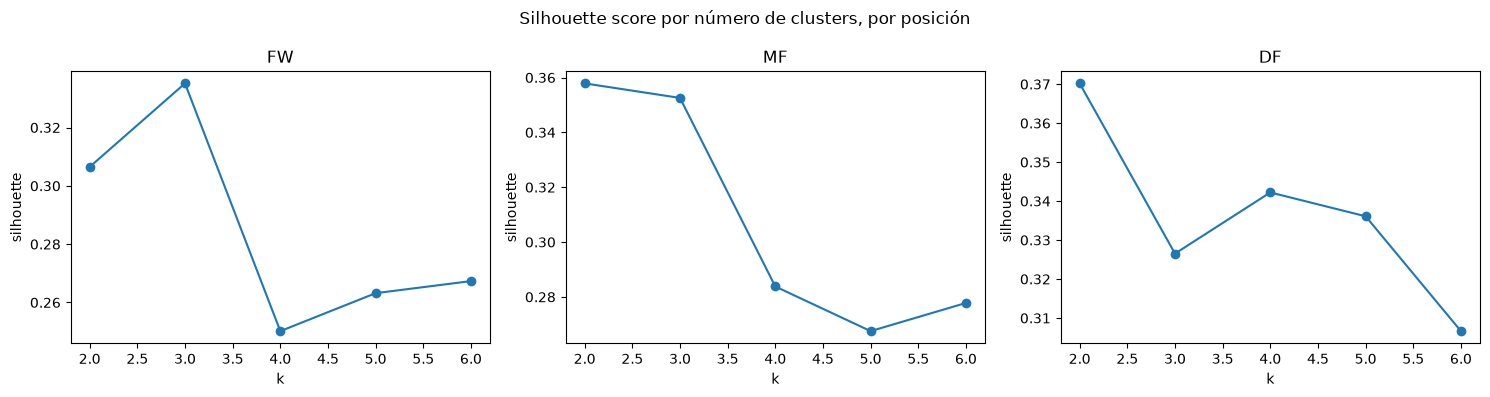

In [2]:
posiciones = ["FW", "MF", "DF"]
resultados_k = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pos in zip(axes, posiciones):
    sub = regulares[regulares["posicion_principal"] == pos][metricas].dropna()
    X = StandardScaler().fit_transform(sub)
    scores = []
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        scores.append(silhouette_score(X, km.labels_))
    resultados_k[pos] = scores
    ax.plot(range(2, 7), scores, marker="o")
    ax.set_title(pos)
    ax.set_xlabel("k")
    ax.set_ylabel("silhouette")
fig.suptitle("Silhouette score por número de clusters, por posición")
fig.tight_layout()

## Ajustar K-Means (k=3) por posición

Etiquetamos los clusters por su nivel de producción ofensiva promedio
(`goals_assists_per90`) — así el cluster "0" no es arbitrario, siempre es
"Bajo", "Medio" o "Alto" sin importar el orden que le dé K-Means internamente.

In [3]:
K = 3
etiquetas_nivel = ["Bajo", "Medio", "Alto"]

resultados = []
modelos = {}
for pos in posiciones:
    sub = regulares[regulares["posicion_principal"] == pos].dropna(subset=metricas).copy()
    X = StandardScaler().fit_transform(sub[metricas])
    km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X)
    sub["cluster_raw"] = km.labels_

    # Reordenamos las etiquetas de cluster por producción ofensiva promedio
    orden = sub.groupby("cluster_raw")["goals_assists_per90"].mean().sort_values().index
    mapa = {cluster_id: etiquetas_nivel[i] for i, cluster_id in enumerate(orden)}
    sub["nivel"] = sub["cluster_raw"].map(mapa)

    modelos[pos] = km
    resultados.append(sub)

clustered = pd.concat(resultados)
clustered["nivel"] = pd.Categorical(clustered["nivel"], categories=etiquetas_nivel, ordered=True)
clustered.groupby(["posicion_principal", "nivel"])[metricas].mean().round(2)

goals_per90  assists_per90  goals_assists_per90  \
posicion_principal nivel                                                    
DF                 Bajo          0.02           0.03                 0.05   
                   Medio         0.03           0.03                 0.06   
                   Alto          0.13           0.09                 0.22   
FW                 Bajo          0.21           0.11                 0.32   
                   Medio         0.31           0.13                 0.44   
                   Alto          0.56           0.19                 0.75   
MF                 Bajo          0.06           0.08                 0.14   
                   Medio         0.09           0.09                 0.17   
                   Alto          0.29           0.21                 0.50   

                          goals_pens_per90  cards_yellow  cards_red  
posicion_principal nivel                                             
DF                 Bajo               0.02          3.62       0.00  
                   Medio              0.03          5.48       1.19  
                   Alto               0.12          3.70       0.14  
FW                 Bajo               0.19          2.38       0.00  
                   Medio              0.28          4.35       1.13  
                   Alto               0.51          2.72       0.03  
MF                 Bajo               0.06          3.71       0.00  
                   Medio              0.08          5.55       1.15  
                   Alto               0.26          2.86       0.07

## Visualización de los clusters

Goles/90 vs. asistencias/90, coloreado por nivel — para confirmar visualmente
que los clusters separan algo con sentido futbolístico.

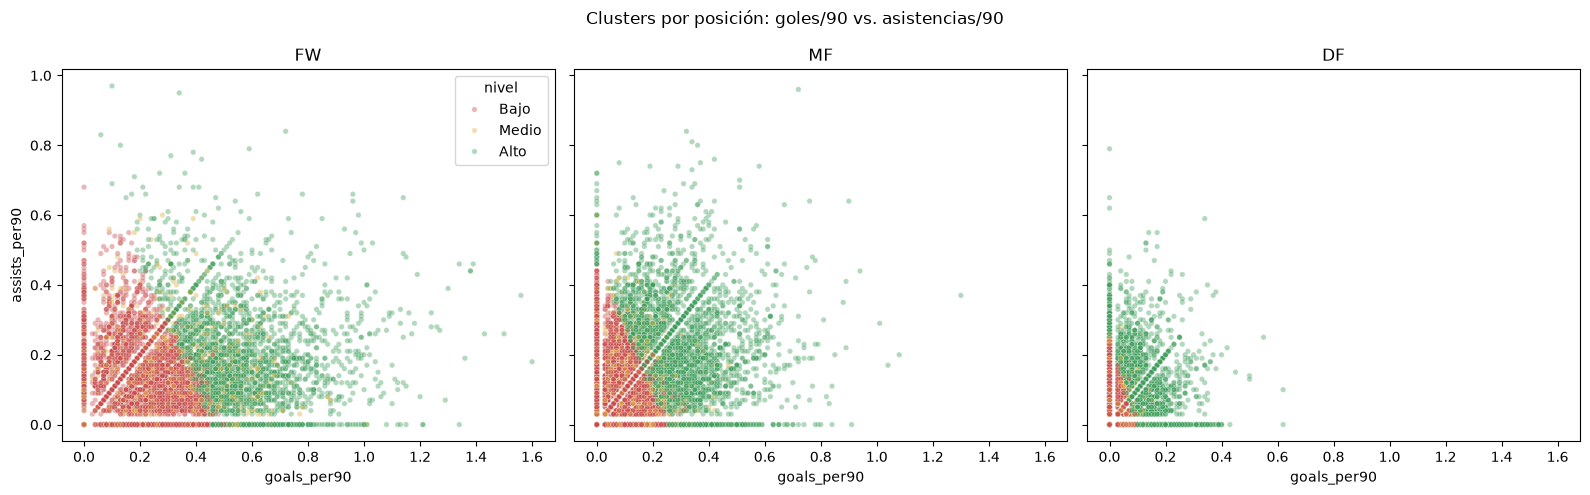

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
paleta = {"Bajo": "#c94c4c", "Medio": "#e0b03e", "Alto": "#3f9e5c"}
for ax, pos in zip(axes, posiciones):
    sub = clustered[clustered["posicion_principal"] == pos]
    sns.scatterplot(
        data=sub, x="goals_per90", y="assists_per90", hue="nivel",
        palette=paleta, alpha=0.4, s=15, ax=ax, legend=(pos == "FW"),
    )
    ax.set_title(pos)
fig.suptitle("Clusters por posición: goles/90 vs. asistencias/90")
fig.tight_layout()

## Comparación de nivel entre ligas

Para cada posición: ¿qué % de los jugadores de cada liga cae en cada nivel?
Una liga con mayor % en "Alto" tiene, en promedio, delanteros/mediocampistas/
defensas con más producción ofensiva relativa — nuestra proxy cuantitativa
de nivel.

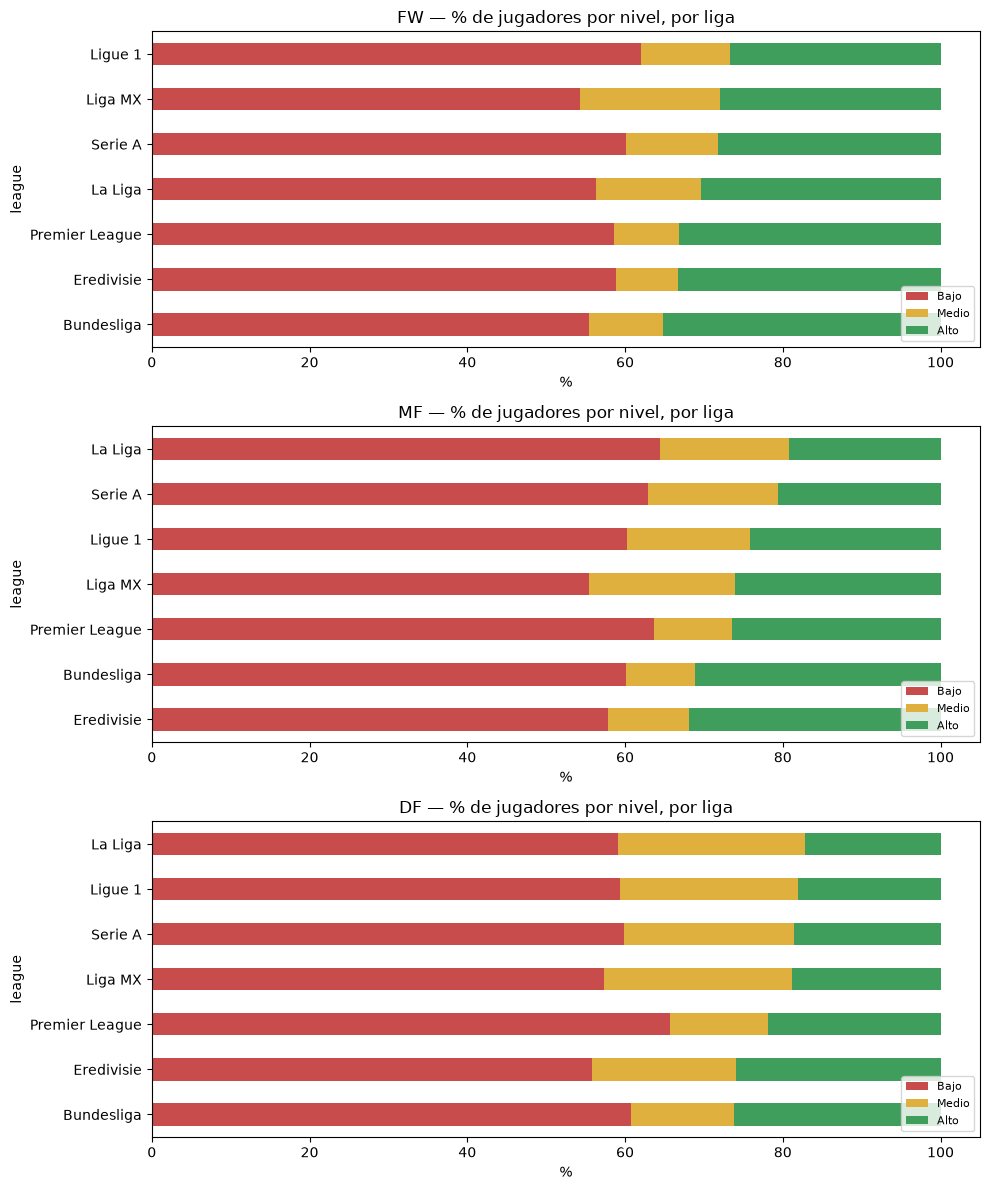

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
for ax, pos in zip(axes, posiciones):
    sub = clustered[clustered["posicion_principal"] == pos]
    tabla = pd.crosstab(sub["league"], sub["nivel"], normalize="index") * 100
    tabla = tabla.sort_values("Alto", ascending=False)
    tabla.plot(kind="barh", stacked=True, color=[paleta[c] for c in tabla.columns], ax=ax)
    ax.set_title(f"{pos} — % de jugadores por nivel, por liga")
    ax.set_xlabel("%")
    ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()

**Cuidado al leer esto**: esta comparación mide *producción ofensiva
relativa dentro del dataset*, no "calidad futbolística" en un sentido
absoluto — una liga más ofensiva/abierta tácticamente puede inflar goles y
asistencias sin que sus jugadores sean necesariamente "mejores" en otras
facetas (defensa, técnica, físico) que no están en estos datos. Es una señal
parcial, no un veredicto.

## Foco en un jugador: ¿en qué cluster cae, temporada a temporada?

In [6]:
jugador_foco = "Robert Lewandowski"  # cambia aquí para ver a otro jugador

trayectoria_cluster = clustered[clustered["player"] == jugador_foco].sort_values("season")
trayectoria_cluster[["season", "team", "league", "posicion_principal", "goals_per90", "assists_per90", "nivel"]]

,season,team,league,posicion_principal,goals_per90,assists_per90,nivel
261,2010-2011,Dortmund,Bundesliga,FW,0.45,0.06,Alto
724,2011-2012,Dortmund,Bundesliga,FW,0.69,0.22,Alto
1219,2012-2013,Dortmund,Bundesliga,FW,0.83,0.17,Alto
1701,2013-2014,Dortmund,Bundesliga,FW,0.64,0.26,Alto
2180,2014-2015,Bayern Munich,Bundesliga,FW,0.62,0.18,Alto
2669,2015-2016,Bayern Munich,Bundesliga,FW,1.02,0.07,Alto
3146,2016-2017,Bayern Munich,Bundesliga,FW,0.97,0.16,Alto
3633,2017-2018,Bayern Munich,Bundesliga,FW,1.20,0.08,Alto
4103,2018-2019,Bayern Munich,Bundesliga,FW,0.67,0.21,Alto
4571,2019-2020,Bayern Munich,Bundesliga,FW,1.11,0.13,Alto


## Siguiente paso

- Repetir esta comparación **por temporada** (no todo el panel junto) para
  ver si el nivel relativo de una liga sube o baja con los años.
- Añadir edad como filtro (ej. comparar solo sub-23) para ver de dónde salen
  las canteras con más nivel relativo.
- Si se consigue más adelante alguna métrica defensiva histórica (no solo la
  de la temporada 2024-25 que ya tenemos), repetir el clustering de
  defensas con esa señal real en vez de solo goles/asistencias/tarjetas.